<a href="https://colab.research.google.com/github/sapnarajawat777/Dream_career_website/blob/main/Housing_Sales_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

In [ ]:
# configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

RANDOM_STATE = 42
CSV_PATH = "Housing.csv"          # update path for a different dataset
TARGET_COL = "median_house_value" # target column name

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Housing.csv to Housing (1).csv


In [ ]:

df = pd.read_csv(CSV_PATH)
df.head()
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
TARGET_COL = "median_house_value"
print(df.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')


In [ ]:
X = df.drop(TARGET_COL, axis=1)
y = df[TARGET_COL]

In [ ]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numeric Columns:")
print(numeric_features)

print("\nCategorical Columns:")
print(categorical_features)

Numeric Columns:
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')

Categorical Columns:
Index(['ocean_proximity'], dtype='object')


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_features = X.select_dtypes(include=["int64","float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['ocean_proximity'], dtype='object'))])),
                ('regressor', LinearRegression())])

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score :", r2_score(y_test, y_pred))

MAE : 50670.48923565593
RMSE : 70059.19333925008
R2 Score : 0.6254382675296274


In [ ]:
result = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

result.head(10)

,Actual Price,Predicted Price
20046,47700.000,54261.028
3024,45800.000,124430.918
15663,500001.000,255694.958
20484,218600.000,268208.010
9814,278000.000,262975.014
13311,158700.000,139811.883
7113,198200.000,290871.003
7668,157500.000,228470.455
18246,340000.000,256712.364
5723,446600.000,408129.437


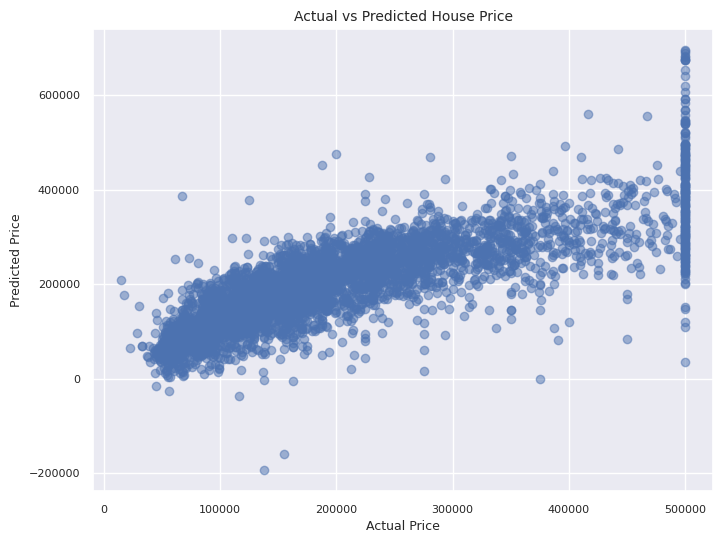

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [ ]:
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score :", r2_score(y_test, rf_pred))

MAE : 31636.34963905039
RMSE : 48977.063518396775
R2 Score : 0.8169462518407672


In [ ]:
result = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

result.head(10)

,Actual Price,Predicted Price
20046,47700.000,54261.028
3024,45800.000,124430.918
15663,500001.000,255694.958
20484,218600.000,268208.010
9814,278000.000,262975.014
13311,158700.000,139811.883
7113,198200.000,290871.003
7668,157500.000,228470.455
18246,340000.000,256712.364
5723,446600.000,408129.437


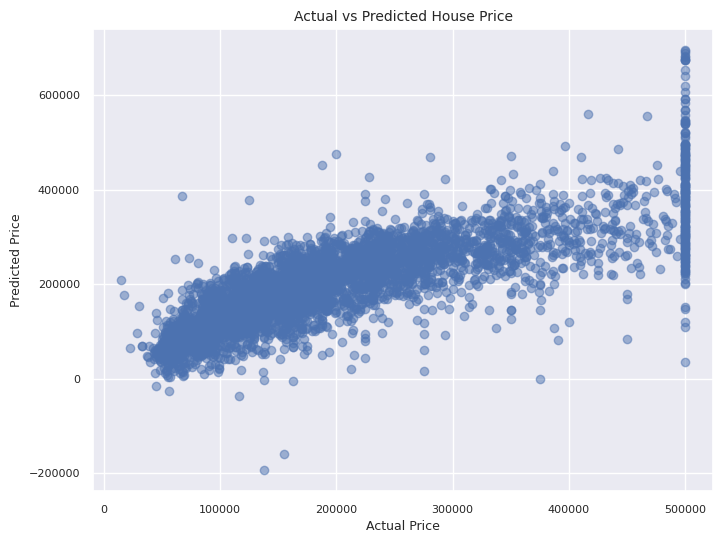

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [ ]:
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score :", r2_score(y_test, rf_pred))

MAE : 31636.34963905039
RMSE : 48977.063518396775
R2 Score : 0.8169462518407672


In [ ]:
result = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

result.head(10)

,Actual Price,Predicted Price
20046,47700.000,54261.028
3024,45800.000,124430.918
15663,500001.000,255694.958
20484,218600.000,268208.010
9814,278000.000,262975.014
13311,158700.000,139811.883
7113,198200.000,290871.003
7668,157500.000,228470.455
18246,340000.000,256712.364
5723,446600.000,408129.437


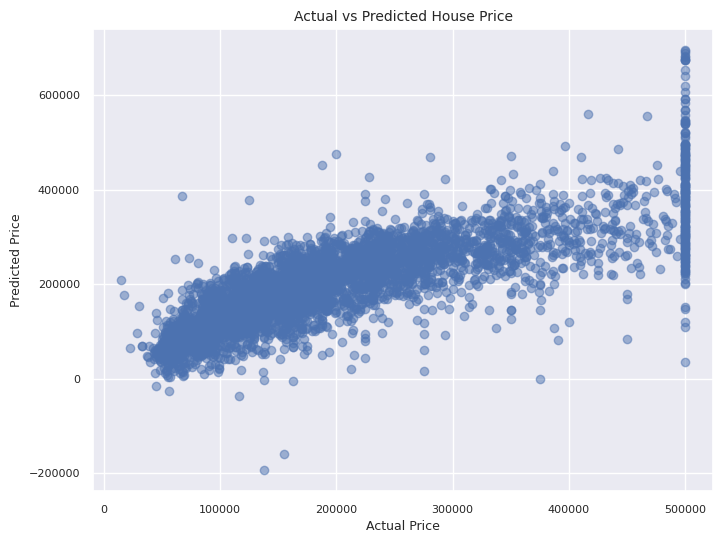

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("=== Random Forest Results ===")
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score :", r2_score(y_test, rf_pred))

=== Random Forest Results ===
MAE : 31636.34963905039
RMSE : 48977.063518396775
R2 Score : 0.8169462518407672


In [ ]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [ ]:
print(preprocess)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['longitude', 'latitude', 'housing_median_age',
                                  'total_rooms', 'total_bedrooms', 'population',
                                  'households', 'median_income']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['ocean_proximity'])])


In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

hgb_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE))
    ]
)

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

hgb_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE))
    ]
)

In [ ]:
from sklearn.model_selection import KFold

k = 5

cv = KFold(
    n_splits=k,
    shuffle=True,
    random_state=RANDOM_STATE
)


In [ ]:
grid = GridSearchCV(
    estimator=hgb_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train)

print("Best CV RMSE:", -grid.best_score_)
print("Best params:", grid.best_params_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best CV RMSE: 47408.38131673431
Best params: {'model__l2_regularization': 0.1, 'model__learning_rate': 0.1, 'model__max_depth': None, 'model__max_leaf_nodes': 63, 'model__min_samples_leaf': 20}


In [ ]:
hgb_best = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", HistGradientBoostingRegressor(
            learning_rate=0.1,
            max_depth=None,
            max_leaf_nodes=63,
            min_samples_leaf=20,
            l2_regularization=0.1,
            random_state=RANDOM_STATE
        ))
    ]
)

hgb_best.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model',
                 HistGradientBoostingRegressor(l2_regularization=0.1,
                                               max_leaf_nodes=63,
                                               random_state=42))])

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

train_pred = hgb_best.predict(X_train)

print("=== Train Performance ===")
print("RMSE:", np.sqrt(mean_squared_error(y_train, train_pred)))
print("MAE :", mean_absolute_error(y_train, train_pred))
print("R2  :", r2_score(y_train, train_pred))

=== Train Performance ===
RMSE: 36086.48428940783
MAE : 24537.337097415126
R2  : 0.9025841132893323


In [ ]:
test_pred = hgb_best.predict(X_test)

print("=== Test Performance ===")
print("RMSE:", np.sqrt(mean_squared_error(y_test, test_pred)))
print("MAE :", mean_absolute_error(y_test, test_pred))
print("R2  :", r2_score(y_test, test_pred))

=== Test Performance ===
RMSE: 46931.20110495814
MAE : 31156.235754702237
R2  : 0.8319198300891739


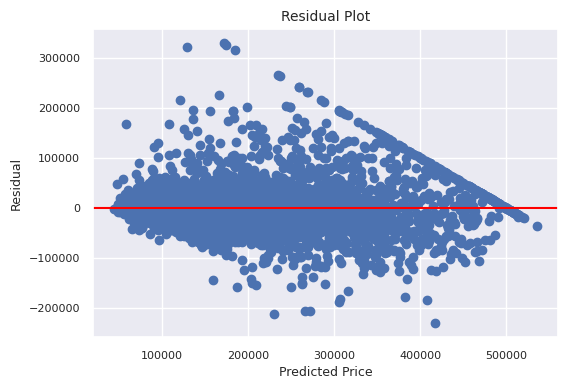

In [ ]:
import matplotlib.pyplot as plt

residuals = y_test - test_pred

plt.figure(figsize=(6,4))
plt.scatter(test_pred, residuals)
plt.axhline(0, color="red")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

In [ ]:
sample = pd.DataFrame({
    "longitude": [-122.23],
    "latitude": [37.88],
    "housing_median_age": [41],
    "total_rooms": [880],
    "total_bedrooms": [129],
    "population": [322],
    "households": [126],
    "median_income": [8.3252],
    "ocean_proximity": ["NEAR BAY"]
})

prediction = hgb_best.predict(sample)

print("Predicted House Price:", prediction[0])